In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
import numpy as np


In [ ]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/archive/Training",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

val_ds = keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/archive/Testing",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)


Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


In [ ]:
class_names = train_ds.class_names
print("Class names:", class_names)


Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = train_ds.map(normalize)
val_ds = val_ds.map(normalize)


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


In [ ]:
base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
model = Sequential([
    data_augmentation,
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax")
])


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40
)

Epoch 1/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 2035s 11s/step - accuracy: 0.5295 - loss: 1.1288 - val_accuracy: 0.7468 - val_loss: 0.6377
Epoch 2/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 30s 169ms/step - accuracy: 0.7719 - loss: 0.6066 - val_accuracy: 0.7750 - val_loss: 0.5863
Epoch 3/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 35s 198ms/step - accuracy: 0.8087 - loss: 0.5187 - val_accuracy: 0.8200 - val_loss: 0.5129
Epoch 4/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 30s 167ms/step - accuracy: 0.8237 - loss: 0.4558 - val_accuracy: 0.8070 - val_loss: 0.5017
Epoch 5/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 30s 169ms/step - accuracy: 0.8515 - loss: 0.4109 - val_accuracy: 0.8413 - val_loss: 0.4234
Epoch 6/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 31s 172ms/step - accuracy: 0.8562 - loss: 0.3973 - val_accuracy: 0.8543 - val_loss: 0.3998
Epoch 7/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 41s 172ms/step - accuracy: 0.8667 - loss: 0.3651 - val_accuracy: 0.8429 - val_loss: 0.4306
Epoch 8/40
179/179 ━━━━━━━━━━━━━━━━━━━━ 40s 169ms/step - accuracy: 0.8738 - loss: 0

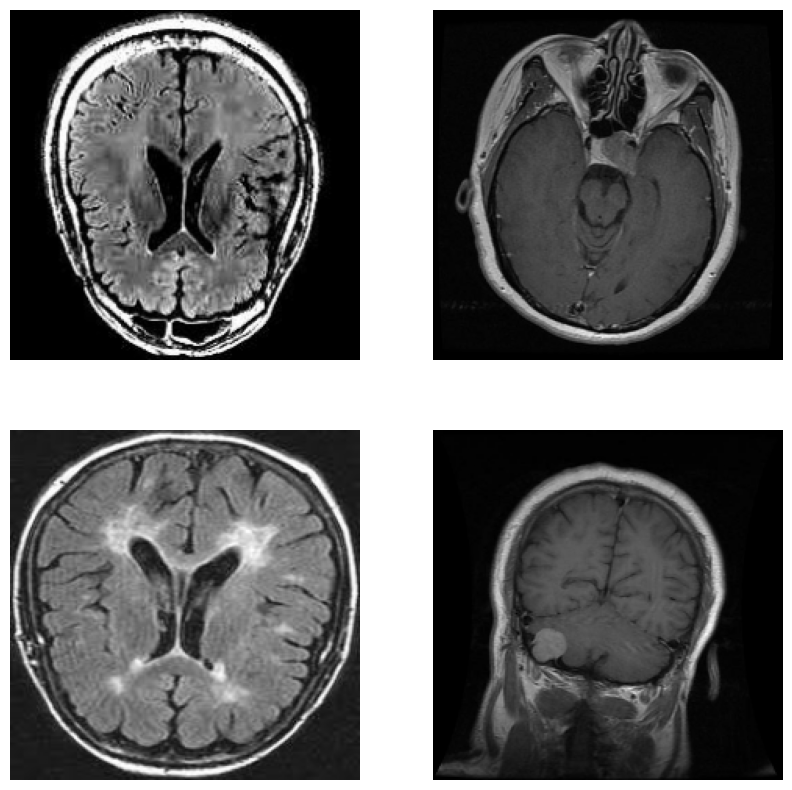

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))

for images, labels in val_ds.take(1):   # take one batch from testing
    for i in range(4):                  # plot 4 images
        ax = plt.subplot(2, 2, i + 1)
        plt.imshow(images[i])
        plt.axis("off")
plt.show()

In [ ]:
import numpy as np

for images, labels in val_ds.take(1):
    preds = model.predict(images)

    pred_class = np.argmax(preds[0])
    true_class = np.argmax(labels[0])

    print("Predicted:", class_names[pred_class])
    print("Actual   :", class_names[true_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step
Predicted: glioma
Actual   : glioma


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


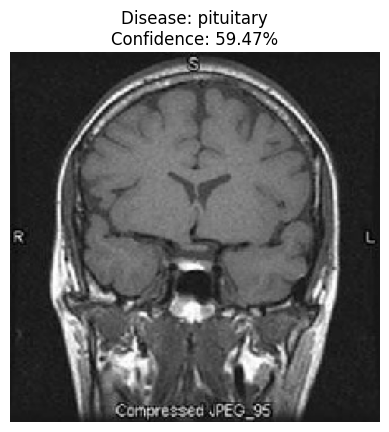

 Predicted Disease: pituitary
 Confidence: 59.47 %


In [ ]:
img_path = "/content/Figure-10.-A-Sagittal-and-B-coronal-noncontrast-T1-weighted-images-1.jpg"   # change path


img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)


predictions = model.predict(img_array)


predicted_index = np.argmax(predictions)
predicted_disease = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100


plt.imshow(img)
plt.axis("off")
plt.title(f"Disease: {predicted_disease}\nConfidence: {confidence:.2f}%")
plt.show()

print(" Predicted Disease:", predicted_disease)
print(" Confidence:", round(confidence, 2), "%")